# Import Libraries

In [25]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Model building
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    roc_auc_score,
    roc_curve,
    confusion_matrix
)

# Load Dataset

In [26]:
# Load your exported NetLogo dataset
df = pd.read_csv("infection_risk_dataset.csv")

# Preview data
print(df.head())

# Check basic info
print(df.info())

   tick  turtle_id          x          y  mobility  infected_neighbors  \
0     0         66 -11.745957 -16.284932         1                   0   
1     0        237  -1.029090  -2.580822         1                   0   
2     0        123   0.447275 -10.749799         1                   0   
3     0        244  -1.260960  -3.762570         1                   0   
4     0        242  -2.211561  -3.561093         1                   0   

   exposed_neighbors  total_neighbors  local_infection_density  \
0                  0                3                      0.0   
1                  0                3                      0.0   
2                  0                5                      0.0   
3                  0                4                      0.0   
4                  0                4                      0.0   

   transmission_rate  transmission_radius  vaccination_rate  \
0                0.3                  1.5                20   
1                0.3            

# Data Preprocessing

In [27]:
# Remove missing values (if any)
df = df.dropna()

# Check class balance

print(df["infected_next_tick"].value_counts(normalize=True))

infected_next_tick
0    0.8094
1    0.1906
Name: proportion, dtype: float64


In [28]:
# Separate features and label
X = df.drop(columns=["infected_next_tick"])
y = df["infected_next_tick"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (41296, 12)
Target shape: (41296,)


In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y   # preserves class balance
)

In [30]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model Development

In [31]:
#Logistic Regression Model
log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train_scaled, y_train)

# Predictions
y_pred_log = log_model.predict(X_test_scaled)
y_prob_log = log_model.predict_proba(X_test_scaled)[:, 1]

In [32]:
#Random Forrest Model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

# Performance Evaluation

In [33]:
print("Logistic Regression Results")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_log))
print(classification_report(y_test, y_pred_log))

Logistic Regression Results
Accuracy: 0.9865203002663653
ROC-AUC: 0.9961823117211662
              precision    recall  f1-score   support

           0       0.99      0.99      0.99     10028
           1       0.95      0.98      0.97      2361

    accuracy                           0.99     12389
   macro avg       0.97      0.98      0.98     12389
weighted avg       0.99      0.99      0.99     12389



In [34]:
print("Random Forest Results")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Results
Accuracy: 0.9933812252804908
ROC-AUC: 0.9998837646795664
              precision    recall  f1-score   support

           0       1.00      0.99      1.00     10028
           1       0.97      1.00      0.98      2361

    accuracy                           0.99     12389
   macro avg       0.98      1.00      0.99     12389
weighted avg       0.99      0.99      0.99     12389



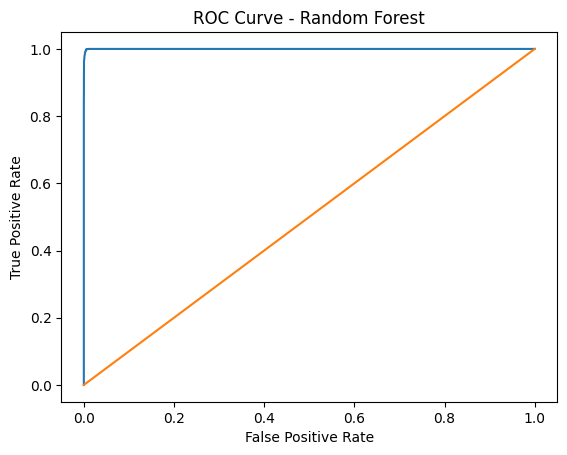

In [35]:
fpr, tpr, _ = roc_curve(y_test, y_prob_rf)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.show()

Confusion Matrix - Random Forest
[[9947   81]
 [   1 2360]]


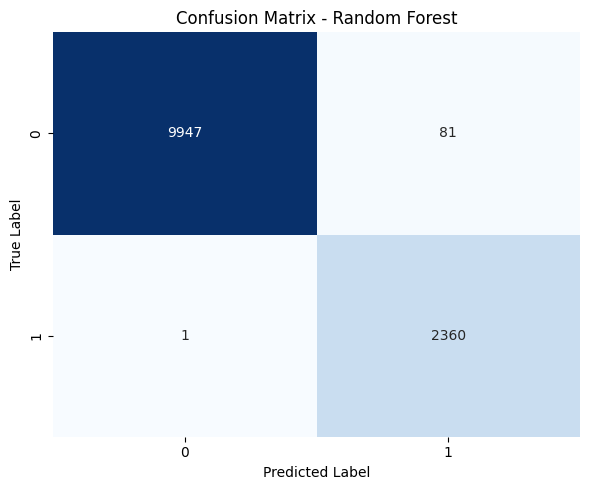

In [36]:
from sklearn.metrics import confusion_matrix
print("Confusion Matrix - Random Forest")
print(confusion_matrix(y_test, y_pred_rf))

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred_rf)

# Plot
plt.figure(figsize=(6,5))
sns.heatmap(cm, 
            annot=True, 
            fmt='d', 
            cmap='Blues', 
            cbar=False)

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

In [37]:
importances = rf_model.feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print(feature_importance_df)

                    Feature  Importance
5        infected_neighbors    0.408716
8   local_infection_density    0.389088
6         exposed_neighbors    0.049620
0                      tick    0.047275
2                         x    0.039880
7           total_neighbors    0.030912
1                 turtle_id    0.020035
3                         y    0.014474
4                  mobility    0.000000
9         transmission_rate    0.000000
10      transmission_radius    0.000000
11         vaccination_rate    0.000000


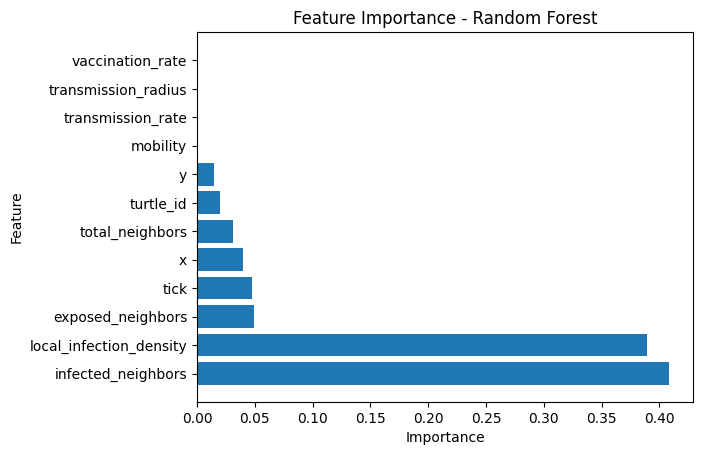

In [38]:
plt.figure()
plt.barh(feature_importance_df["Feature"], feature_importance_df["Importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance - Random Forest")
plt.show()

In [39]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(rf_model, X, y, cv=5, scoring="roc_auc")

print("Cross-validation ROC-AUC:", cv_scores.mean())

Cross-validation ROC-AUC: 0.983634481113285


# Prediction Test

In [40]:
sample = np.array([[10, 45, 3.2, -1.5, 1.0, 2, 1, 5, 0.4, 0.25, 2, 10]])

prob = rf_model.predict_proba(sample)[:, 1]
print("Infection Risk:", prob[0])

Infection Risk: 0.54


C:\Users\MSI-G\anaconda3\envs\tf\lib\site-packages\sklearn\base.py:465: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
